# Feature Selection
## Random Forest

In [1]:
1+1

2

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
#from sklearn.datasets import load_breast_cancer

In [2]:
import datetime

In [3]:
# 1. Load dataset with indicators
data = pd.read_csv('C:\\Users\\cris_\\OneDrive\\CBS\\MSc_Data_Science\\ml_dl\\final_project\\oil_price\\ML-Final-Project\\data\\processed\\final_dataset_with_indicators.csv')

In [4]:
df = data.loc[:,~data.columns.isin(['Ucome_fob_ARA', 'Unnamed: 0'])]

df.head()

,Date,HVO_class_II_fob_ARA,UCO_exw_ARA,EU_BRENT_CRUDE,LSMGO_Rotterdam,EUR_USD_rate,Rate,FuelEU_MGO_penalty,HVO_class_II_fob_ARA_SMA_20,HVO_class_II_fob_ARA_SMA_50,...,LSMGO_Rotterdam_KST,LSMGO_Rotterdam_PSL,LSMGO_Rotterdam_MSTD_20,LSMGO_Rotterdam_MVAR_20,LSMGO_Rotterdam_BB_Upper,LSMGO_Rotterdam_BB_Lower,LSMGO_Rotterdam_BB_Middle,LSMGO_Rotterdam_KER_20,LSMGO_Rotterdam_DMA_20_50,LSMGO_Rotterdam_MAD_20
0,2021-04-26,1965.05,1310.390,65.65,503.0,0.8280,0.07,0.0,1965.050000,1965.050000,...,0.0,0.000000,NaN,NaN,NaN,NaN,503.000000,0.0,0.0,0.0
1,2021-04-27,1968.09,1310.390,66.42,516.0,0.8280,0.07,0.0,1966.570000,1966.570000,...,0.0,8.333333,9.192388,84.500000,527.884776,491.115224,509.500000,0.0,0.0,0.0
2,2021-04-28,1982.93,1312.605,67.27,521.0,0.8266,0.07,0.0,1972.023333,1972.023333,...,0.0,16.666667,9.291573,86.333333,531.916480,494.750187,513.333333,0.0,0.0,0.0
3,2021-04-29,1987.52,1320.735,68.56,528.0,0.8253,0.06,0.0,1975.897500,1975.897500,...,0.0,25.000000,10.551461,111.333333,538.102922,495.897078,517.000000,0.0,0.0,0.0
4,2021-04-30,1983.18,1311.200,67.25,523.0,0.8313,0.05,0.0,1977.354000,1977.354000,...,0.0,25.000000,9.523655,90.700000,537.247310,499.152690,518.200000,0.0,0.0,0.0


In [5]:
exclude = "Ucome"
df = df.loc[:, ~df.columns.str.contains(exclude, case=False, na=False)]

In [6]:
df.head()

,Date,HVO_class_II_fob_ARA,UCO_exw_ARA,EU_BRENT_CRUDE,LSMGO_Rotterdam,EUR_USD_rate,Rate,FuelEU_MGO_penalty,HVO_class_II_fob_ARA_SMA_20,HVO_class_II_fob_ARA_SMA_50,...,LSMGO_Rotterdam_KST,LSMGO_Rotterdam_PSL,LSMGO_Rotterdam_MSTD_20,LSMGO_Rotterdam_MVAR_20,LSMGO_Rotterdam_BB_Upper,LSMGO_Rotterdam_BB_Lower,LSMGO_Rotterdam_BB_Middle,LSMGO_Rotterdam_KER_20,LSMGO_Rotterdam_DMA_20_50,LSMGO_Rotterdam_MAD_20
0,2021-04-26,1965.05,1310.390,65.65,503.0,0.8280,0.07,0.0,1965.050000,1965.050000,...,0.0,0.000000,NaN,NaN,NaN,NaN,503.000000,0.0,0.0,0.0
1,2021-04-27,1968.09,1310.390,66.42,516.0,0.8280,0.07,0.0,1966.570000,1966.570000,...,0.0,8.333333,9.192388,84.500000,527.884776,491.115224,509.500000,0.0,0.0,0.0
2,2021-04-28,1982.93,1312.605,67.27,521.0,0.8266,0.07,0.0,1972.023333,1972.023333,...,0.0,16.666667,9.291573,86.333333,531.916480,494.750187,513.333333,0.0,0.0,0.0
3,2021-04-29,1987.52,1320.735,68.56,528.0,0.8253,0.06,0.0,1975.897500,1975.897500,...,0.0,25.000000,10.551461,111.333333,538.102922,495.897078,517.000000,0.0,0.0,0.0
4,2021-04-30,1983.18,1311.200,67.25,523.0,0.8313,0.05,0.0,1977.354000,1977.354000,...,0.0,25.000000,9.523655,90.700000,537.247310,499.152690,518.200000,0.0,0.0,0.0


In [7]:
# df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')

In [8]:
df[df['Date']=='2022-03-16']

,Date,HVO_class_II_fob_ARA,UCO_exw_ARA,EU_BRENT_CRUDE,LSMGO_Rotterdam,EUR_USD_rate,Rate,FuelEU_MGO_penalty,HVO_class_II_fob_ARA_SMA_20,HVO_class_II_fob_ARA_SMA_50,...,LSMGO_Rotterdam_KST,LSMGO_Rotterdam_PSL,LSMGO_Rotterdam_MSTD_20,LSMGO_Rotterdam_MVAR_20,LSMGO_Rotterdam_BB_Upper,LSMGO_Rotterdam_BB_Lower,LSMGO_Rotterdam_BB_Middle,LSMGO_Rotterdam_KER_20,LSMGO_Rotterdam_DMA_20_50,LSMGO_Rotterdam_MAD_20
324,2022-03-16,3171.31,1738.75,98.02,927.0,0.9087,0.08,0.0,3273.39,3132.5544,...,318.967847,41.666667,158.654006,25171.093567,1366.808012,732.191988,1049.5,0.04455,189.76,130.3


In [9]:
df_pre = df.iloc[1:325,:]

In [10]:
df_after = df.iloc[325:,:]

In [11]:
y_pre = data['Ucome_fob_ARA'].iloc[1:325]

In [12]:
y_after = data['Ucome_fob_ARA'].iloc[325:]

X as a df

In [13]:
X= df_pre.drop(columns=['Date'])
y = y_pre.reset_index(drop=True)

In [14]:
X.head()

,HVO_class_II_fob_ARA,UCO_exw_ARA,EU_BRENT_CRUDE,LSMGO_Rotterdam,EUR_USD_rate,Rate,FuelEU_MGO_penalty,HVO_class_II_fob_ARA_SMA_20,HVO_class_II_fob_ARA_SMA_50,HVO_class_II_fob_ARA_EMA_12,...,LSMGO_Rotterdam_KST,LSMGO_Rotterdam_PSL,LSMGO_Rotterdam_MSTD_20,LSMGO_Rotterdam_MVAR_20,LSMGO_Rotterdam_BB_Upper,LSMGO_Rotterdam_BB_Lower,LSMGO_Rotterdam_BB_Middle,LSMGO_Rotterdam_KER_20,LSMGO_Rotterdam_DMA_20_50,LSMGO_Rotterdam_MAD_20
1,1968.0900,1310.39000,66.420000,516.000000,0.82800,0.070000,0.0,1966.570000,1966.570000,1966.696667,...,0.0,8.333333,9.192388,84.500000,527.884776,491.115224,509.500000,0.0,0.0,0.0
2,1982.9300,1312.60500,67.270000,521.000000,0.82660,0.070000,0.0,1972.023333,1972.023333,1973.032540,...,0.0,16.666667,9.291573,86.333333,531.916480,494.750187,513.333333,0.0,0.0,0.0
3,1987.5200,1320.73500,68.560000,528.000000,0.82530,0.060000,0.0,1975.897500,1975.897500,1977.605665,...,0.0,25.000000,10.551461,111.333333,538.102922,495.897078,517.000000,0.0,0.0,0.0
4,1983.1800,1311.20000,67.250000,523.000000,0.83130,0.050000,0.0,1977.354000,1977.354000,1979.120192,...,0.0,25.000000,9.523655,90.700000,537.247310,499.152690,518.200000,0.0,0.0,0.0
5,1987.8975,1310.80625,67.353333,524.666667,0.83155,0.053333,0.0,1979.111250,1979.111250,1981.253540,...,0.0,33.333333,8.917939,79.529630,537.113655,501.441900,519.277778,0.0,0.0,0.0


In [15]:
X

,HVO_class_II_fob_ARA,UCO_exw_ARA,EU_BRENT_CRUDE,LSMGO_Rotterdam,EUR_USD_rate,Rate,FuelEU_MGO_penalty,HVO_class_II_fob_ARA_SMA_20,HVO_class_II_fob_ARA_SMA_50,HVO_class_II_fob_ARA_EMA_12,...,LSMGO_Rotterdam_KST,LSMGO_Rotterdam_PSL,LSMGO_Rotterdam_MSTD_20,LSMGO_Rotterdam_MVAR_20,LSMGO_Rotterdam_BB_Upper,LSMGO_Rotterdam_BB_Lower,LSMGO_Rotterdam_BB_Middle,LSMGO_Rotterdam_KER_20,LSMGO_Rotterdam_DMA_20_50,LSMGO_Rotterdam_MAD_20
1,1968.090000,1310.39000,66.420000,516.000000,0.82800,0.070000,0.0,1966.570000,1966.570000,1966.696667,...,0.000000,8.333333,9.192388,84.500000,527.884776,491.115224,509.500000,0.000000,0.000000,0.00
2,1982.930000,1312.60500,67.270000,521.000000,0.82660,0.070000,0.0,1972.023333,1972.023333,1973.032540,...,0.000000,16.666667,9.291573,86.333333,531.916480,494.750187,513.333333,0.000000,0.000000,0.00
3,1987.520000,1320.73500,68.560000,528.000000,0.82530,0.060000,0.0,1975.897500,1975.897500,1977.605665,...,0.000000,25.000000,10.551461,111.333333,538.102922,495.897078,517.000000,0.000000,0.000000,0.00
4,1983.180000,1311.20000,67.250000,523.000000,0.83130,0.050000,0.0,1977.354000,1977.354000,1979.120192,...,0.000000,25.000000,9.523655,90.700000,537.247310,499.152690,518.200000,0.000000,0.000000,0.00
5,1987.897500,1310.80625,67.353333,524.666667,0.83155,0.053333,0.0,1979.111250,1979.111250,1981.253540,...,0.000000,33.333333,8.917939,79.529630,537.113655,501.441900,519.277778,0.000000,0.000000,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320,3258.486667,1731.70000,110.746667,1026.000000,0.91240,0.080000,0.0,3254.013333,3113.333733,3313.018612,...,391.729328,66.666667,178.606120,31900.146199,1381.712241,667.287759,1024.500000,0.216529,284.880000,151.75
321,3241.153333,1733.60000,108.823333,1016.000000,0.91140,0.080000,0.0,3262.022500,3118.888200,3301.962415,...,386.614348,58.333333,171.786706,29510.672515,1378.073413,690.926587,1034.500000,0.198020,271.620000,142.45
322,3223.820000,1735.50000,106.900000,1006.000000,0.91040,0.080000,0.0,3268.645000,3124.218000,3289.940505,...,376.492295,50.000000,165.474235,27381.722515,1373.998470,712.101530,1043.050000,0.170829,254.640000,135.46
323,3157.250000,1729.99000,99.910000,913.000000,0.91330,0.080000,0.0,3272.143000,3128.338400,3269.526581,...,351.271944,41.666667,160.896228,25887.596199,1368.942456,725.357544,1047.150000,0.075229,224.533333,132.18


y as a np array

In [16]:
y

0      1591.7500
1      1605.4500
2      1607.1900
3      1609.7700
4      1614.3725
         ...    
319    2050.9700
320    2061.6100
321    2072.2500
322    2136.3000
323    2137.2000
Name: Ucome_fob_ARA, Length: 324, dtype: float64

In [17]:
# 2. Initialize and train the Random Forest with 100 trees as a baseline
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [18]:
# 3. View the raw importance scores
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

In [19]:
print("Top 15 Features:")
print(importances.head(15))

Top 15 Features:
HVO_class_II_fob_ARA_SMA_50         0.694770
HVO_class_II_fob_ARA_PPO            0.069974
HVO_class_II_fob_ARA_TRIX           0.034053
HVO_class_II_fob_ARA_MACD_Signal    0.023075
HVO_class_II_fob_ARA_MACD           0.020212
LSMGO_Rotterdam_DMA_20_50           0.014942
LSMGO_Rotterdam_MAD_20              0.014378
HVO_class_II_fob_ARA_EMA_26         0.009289
HVO_class_II_fob_ARA_SMA_20         0.008995
UCO_exw_ARA_BB_Lower                0.006583
HVO_class_II_fob_ARA_BB_Lower       0.005219
UCO_exw_ARA_SMA_20                  0.004791
EU_BRENT_CRUDE_DMA_20_50            0.004689
UCO_exw_ARA_DMA_20_50               0.003777
UCO_exw_ARA_EMA_26                  0.003137
dtype: float64


In [20]:
# 4. Use SelectFromModel to filter features
# This uses a threshold (e.g., 'median' or a specific number)
selector = SelectFromModel(rf, threshold='median', prefit=True)
X_important = selector.transform(X)
print(f"\nOriginal shape: {X.shape}")
print(f"Reduced shape: {X_important.shape}")


Original shape: (324, 111)
Reduced shape: (324, 56)


c:\Users\cris_\OneDrive\CBS\MSc_Data_Science\cbs_venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


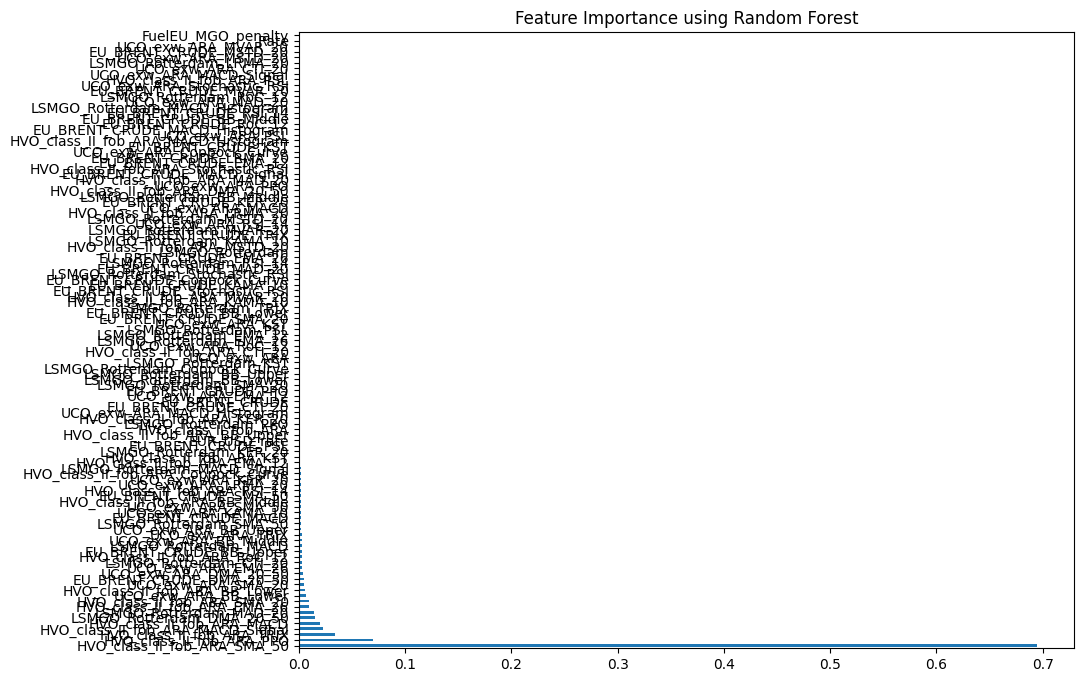

In [21]:
# 5. Visualize the importance
importances.plot(kind='barh', figsize=(10, 8))
plt.title("Feature Importance using Random Forest")
plt.show()

### After Hike

In [22]:
X= df_after.drop(columns=['Date'])
y = y_after.reset_index(drop=True)

In [23]:
# 2. Initialize and train the Random Forest with 100 trees as a baseline
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [24]:
# 3. View the raw importance scores
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

In [25]:
print("Top 15 Features:")
print(importances.head(15))

Top 15 Features:
HVO_class_II_fob_ARA_SMA_50      0.489422
Rate                             0.192017
HVO_class_II_fob_ARA_BB_Lower    0.155065
UCO_exw_ARA                      0.060009
UCO_exw_ARA_BB_Lower             0.017563
UCO_exw_ARA_KAMA_10              0.012826
UCO_exw_ARA_MACD                 0.006696
UCO_exw_ARA_TRIX                 0.006334
UCO_exw_ARA_LRMA_20              0.005307
UCO_exw_ARA_RSI_14               0.004968
LSMGO_Rotterdam_SMA_50           0.004705
UCO_exw_ARA_EMA_12               0.003909
EU_BRENT_CRUDE_BB_Middle         0.002533
EU_BRENT_CRUDE_SMA_50            0.002326
LSMGO_Rotterdam_EMA_26           0.002058
dtype: float64


In [26]:
# 4. Use SelectFromModel to filter features
# This uses a threshold (e.g., 'median' or a specific number)
selector = SelectFromModel(rf, threshold='median', prefit=True)
X_important = selector.transform(X)
print(f"\nOriginal shape: {X.shape}")
print(f"Reduced shape: {X_important.shape}")


Original shape: (1499, 111)
Reduced shape: (1499, 56)


c:\Users\cris_\OneDrive\CBS\MSc_Data_Science\cbs_venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


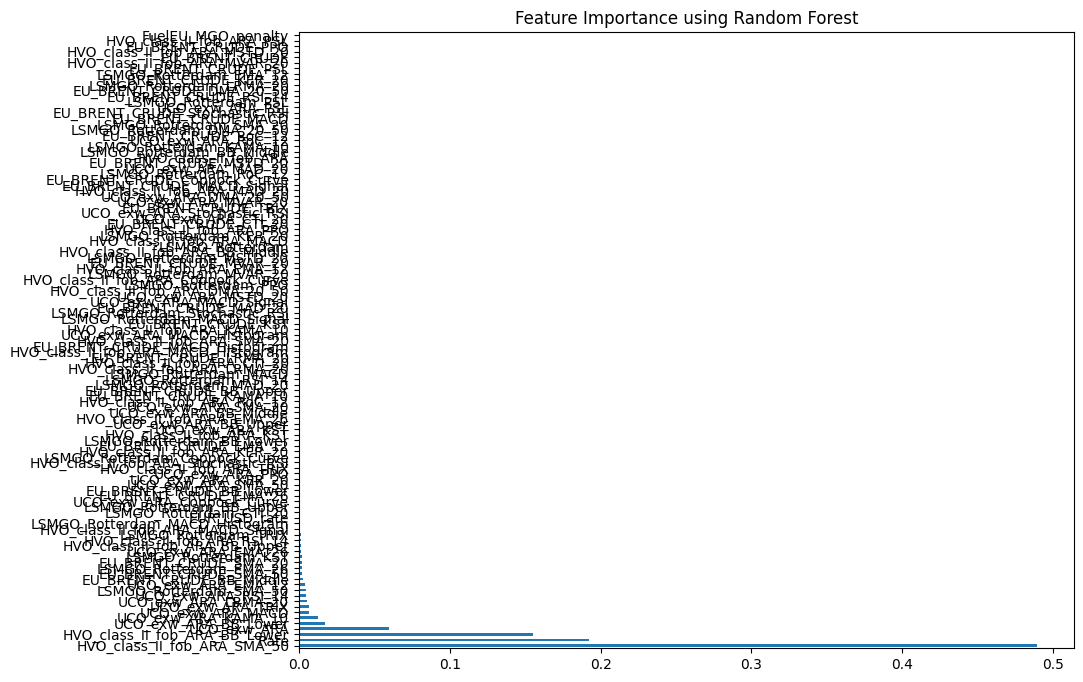

In [27]:
# 5. Visualize the importance
importances.plot(kind='barh', figsize=(10, 8))
plt.title("Feature Importance using Random Forest")
plt.show()

### Adding a breakpoint

,HVO_class_II_fob_ARA,UCO_exw_ARA,EU_BRENT_CRUDE,LSMGO_Rotterdam,EUR_USD_rate,Rate,FuelEU_MGO_penalty,HVO_class_II_fob_ARA_SMA_20,HVO_class_II_fob_ARA_SMA_50,HVO_class_II_fob_ARA_EMA_12,...,LSMGO_Rotterdam_KST,LSMGO_Rotterdam_PSL,LSMGO_Rotterdam_MSTD_20,LSMGO_Rotterdam_MVAR_20,LSMGO_Rotterdam_BB_Upper,LSMGO_Rotterdam_BB_Lower,LSMGO_Rotterdam_BB_Middle,LSMGO_Rotterdam_KER_20,LSMGO_Rotterdam_DMA_20_50,LSMGO_Rotterdam_MAD_20
1031,1560.32,1032.655000,83.030000,807.000000,0.924800,5.33,0.0,1601.717000,1657.1406,1588.334568,...,44.609590,33.333333,21.770708,473.963743,847.841417,760.758583,804.300000,0.024096,30.640000,17.490000
1032,1559.61,1038.400000,83.670000,775.000000,0.924500,5.33,0.0,1598.355500,1651.7820,1583.915403,...,37.967191,33.333333,21.906874,479.911111,848.013747,760.386253,804.200000,0.011628,24.040000,17.560000
1033,1553.67,1038.620000,81.620000,777.000000,0.924300,5.33,0.0,1595.262333,1646.6812,1579.262264,...,31.206432,41.666667,21.949836,481.795322,848.066340,760.266994,804.166667,0.003846,17.420000,17.583333
1034,1555.91,1041.368333,81.923333,776.666667,0.923467,5.33,0.0,1592.846500,1642.2464,1575.669608,...,23.274559,41.666667,22.055983,486.466374,848.195299,759.971368,804.083333,0.009634,11.393333,17.641667
1035,1558.15,1044.116667,82.226667,776.333333,0.922633,5.33,0.0,1591.108000,1637.9810,1572.974284,...,17.670896,33.333333,22.223026,493.862865,848.396051,759.503949,803.950000,0.015444,8.833333,17.740000
1036,1560.39,1046.865000,82.530000,776.000000,0.921800,5.33,0.0,1588.930500,1633.8850,1571.038240,...,12.438753,33.333333,22.155485,490.865497,848.310969,759.689031,804.000000,0.005917,5.240000,17.700000
1037,1565.20,1047.205000,83.650000,790.000000,0.921500,5.33,0.0,1587.034500,1630.0098,1570.140049,...,7.688253,41.666667,22.155485,490.865497,848.310969,759.689031,804.000000,0.000000,2.860000,17.700000
1038,1536.73,1045.505000,83.680000,785.000000,0.923000,5.33,0.0,1582.631500,1625.0830,1565.000042,...,1.778085,33.333333,22.554781,508.718129,848.309561,758.090439,803.200000,0.098765,0.460000,18.340000
1039,1544.27,1043.135000,83.620000,770.000000,0.925100,5.33,0.0,1577.454500,1620.2528,1561.810805,...,-6.326173,33.333333,22.330348,498.644444,844.560696,755.239304,799.900000,0.464789,-2.520000,18.010000
1040,1566.67,1044.710000,83.550000,777.000000,0.923700,5.33,0.0,1574.014333,1617.4092,1562.558373,...,-11.469299,41.666667,21.335225,455.191813,839.703783,754.362884,797.033333,0.389140,-5.960000,17.433333


In [30]:
X= df_after.drop(columns=['Date'])
y = y_after.reset_index(drop=True)

In [31]:
# 2. Initialize and train the Random Forest with 100 trees as a baseline
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [32]:
# 3. View the raw importance scores
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

In [ ]:
print("Top 15 Features:")
print(importances.head(15))

Top 5 Features:
HVO_class_II_fob_ARA_SMA_50      0.489422
Rate                             0.192017
HVO_class_II_fob_ARA_BB_Lower    0.155065
UCO_exw_ARA                      0.060009
UCO_exw_ARA_BB_Lower             0.017563
UCO_exw_ARA_KAMA_10              0.012826
UCO_exw_ARA_MACD                 0.006696
UCO_exw_ARA_TRIX                 0.006334
UCO_exw_ARA_LRMA_20              0.005307
UCO_exw_ARA_RSI_14               0.004968
LSMGO_Rotterdam_SMA_50           0.004705
UCO_exw_ARA_EMA_12               0.003909
EU_BRENT_CRUDE_BB_Middle         0.002533
EU_BRENT_CRUDE_SMA_50            0.002326
LSMGO_Rotterdam_EMA_26           0.002058
dtype: float64


In [ ]:
# 4. Use SelectFromModel to filter features
# This uses a threshold (e.g., 'median' or a specific number)
selector = SelectFromModel(rf, threshold='median', prefit=True)
X_important = selector.transform(X)
print(f"\nOriginal shape: {X.shape}")
print(f"Reduced shape: {X_important.shape}")


Original shape: (324, 111)
Reduced shape: (324, 56)


c:\Users\cris_\OneDrive\CBS\MSc_Data_Science\cbs_venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


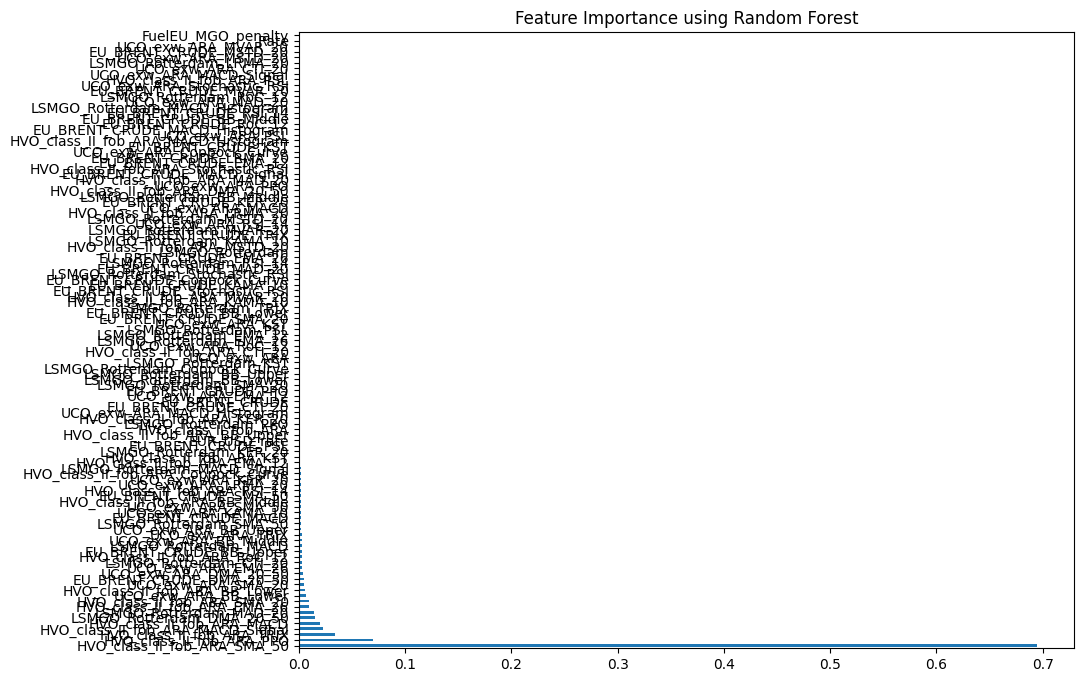

In [ ]:
# 5. Visualize the importance
importances.plot(kind='barh', figsize=(10, 8))
plt.title("Feature Importance using Random Forest")
plt.show()